# L5b Advanced: Frontier Geometry and the Two-Fund Theorem

The L5b lecture stated the closed form of the unconstrained minimum-variance frontier, a hyperbola in the risk-growth plane, and solved the long-only problem numerically. This notebook fills in the geometry. We derive the closed-form weights for every target growth rate, check them against a numerical solver, show that every frontier portfolio is a combination of two fixed frontier portfolios (the two-fund theorem), and then measure what short-sale constraints of increasing severity do to the frontier.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Write the frontier in closed form:** Solve the equality-constrained minimum-variance problem for any target growth rate with two Lagrange multipliers, obtain the weights and the hyperbola, and verify both against a numerical solver.
> - **State and check the two-fund theorem:** Show that every unconstrained frontier portfolio is an affine combination of the global minimum-variance portfolio and one other frontier portfolio, and that mixing two frontier portfolios traces the whole hyperbola.
> - **Measure the cost of constraints:** Compute the frontier under a short-sale limit and under a long-only constraint, and quantify how much variance each constraint adds at a given target.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the course training dataset and the thirteen firms of the L5b min-var example. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `VLQuantitativeFinancePackage.jl` package](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the dataset and the growth-rate matrix, [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, the `LinearAlgebra`, `Statistics`, and `Random` standard libraries, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables, and [the `JuMP.jl` package](https://jump.dev/JuMP.jl/stable/) with the [MadNLP](https://github.com/MadNLP/MadNLP.jl) solver for the constrained problems. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data
We use the daily open-high-low-close data for the firms in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024` (the training data of the L4b, L5a, and L5b examples), loaded with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), and the same thirteen firms as the L5b min-var example. We build the growth-rate matrix with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) and estimate the mean growth-rate vector $\hat{\mathbf{g}}$ and the growth-rate covariance $\hat{\mathbf{\Sigma}}_{g}$ (units: inverse years and inverse years squared). We store them in the `ĝ::Array{Float64,1}` and `Σ̂_g::Array{Float64,2}` variables:

In [3]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # M = 13 firms
ĝ, Σ̂_g = let
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict(k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days);
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = 1/252); # growth rates, N × M
    (mean(G, dims=1) |> vec, cov(G, dims=1))
end;
M = length(my_list_of_tickers);
@assert isposdef(Σ̂_g)
println("M = $(M) firms; positive definite covariance: yes")

M = 13 firms; positive definite covariance: yes


___

## 1. The closed-form frontier
The unconstrained target-growth problem of the lecture, with the target as an equality, is:
$$
\min_{\mathbf{w}}\;\tfrac{1}{2}\mathbf{w}^{\top}\mathbf{\Sigma}_{g}\mathbf{w}\quad\text{subject to}\quad\mathbf{1}^{\top}\mathbf{w}=1,\quad\bar{\mathbf{g}}^{\top}\mathbf{w}=g_{\star}
$$
With multipliers $\lambda$ (budget) and $\gamma$ (target), stationarity gives $\mathbf{\Sigma}_{g}\mathbf{w}=\lambda\mathbf{1}+\gamma\bar{\mathbf{g}}$, so $\mathbf{w}=\lambda\mathbf{\Sigma}_{g}^{-1}\mathbf{1}+\gamma\mathbf{\Sigma}_{g}^{-1}\bar{\mathbf{g}}$. Imposing the two constraints and writing $a=\mathbf{1}^{\top}\mathbf{\Sigma}_{g}^{-1}\mathbf{1}$, $b=\mathbf{1}^{\top}\mathbf{\Sigma}_{g}^{-1}\bar{\mathbf{g}}$, $c=\bar{\mathbf{g}}^{\top}\mathbf{\Sigma}_{g}^{-1}\bar{\mathbf{g}}$, and $d=ac-b^{2}$ gives the linear system $a\lambda+b\gamma=1$, $b\lambda+c\gamma=g_{\star}$, whose solution is:
$$
\lambda(g_{\star})=\frac{c-b\,g_{\star}}{d},\qquad\gamma(g_{\star})=\frac{a\,g_{\star}-b}{d}
$$
and the minimum variance is $\mathbf{w}^{\top}\mathbf{\Sigma}_{g}\mathbf{w}=\lambda+\gamma g_{\star}=(a g_{\star}^{2}-2b g_{\star}+c)/d$, the hyperbola of the lecture. Note $d>0$ by the Cauchy-Schwarz inequality whenever $\bar{\mathbf{g}}$ is not a multiple of $\mathbf{1}$. Let's code the closed form (the function `frontier_weights` in the next cell) and compute the four scalars:

In [4]:
a, b, c, d = let
    x = Σ̂_g \ ones(M); y = Σ̂_g \ ĝ;
    a = ones(M)'*x; b = ones(M)'*y; c = ĝ'*y;
    (a, b, c, a*c - b^2)
end;
@assert d > 0
frontier_weights(g_target) = ((c - b*g_target)/d)*(Σ̂_g \ ones(M)) + ((a*g_target - b)/d)*(Σ̂_g \ ĝ); # closed-form frontier weights
frontier_variance(g_target) = (a*g_target^2 - 2*b*g_target + c)/d; # closed-form minimum variance
println("GMV growth rate b/a = $(round(b/a, digits=4)) 1/yr, GMV std sqrt(1/a) = $(round(sqrt(1/a), digits=4)) 1/yr")

GMV growth rate b/a = 0.0836 1/yr, GMV std sqrt(1/a) = 2.1635 1/yr


Is the closed form right? We check it against a numerical solution of the same equality-constrained problem, built directly in [JuMP](https://jump.dev/JuMP.jl/stable/) with the [MadNLP](https://github.com/MadNLP/MadNLP.jl) solver (the course package's Markowitz type uses a floor target and box bounds, so here we write the equality version ourselves). The function `solve_frontier_point` defined below returns the minimum-variance weights for target `g⋆` with box bounds on the weights, which we will reuse in section 3:

In [5]:
function solve_frontier_point(g_target::Float64; lower::Float64 = -Inf, upper::Float64 = Inf)
    model = Model(() -> MadNLP.Optimizer(print_level = MadNLP.ERROR, max_iter = 500));
    @variable(model, lower ≤ w[i = 1:M] ≤ upper, start = 1/M);
    @objective(model, Min, w'*Σ̂_g*w);
    @constraint(model, sum(w) == 1.0);
    @constraint(model, ĝ'*w == g_target);
    optimize!(model);
    is_solved_and_feasible(model) || return nothing
    return value.(w)
end;

let
    for g_target ∈ [0.05, 0.20, 0.40]
        w_closed = frontier_weights(g_target); w_num = solve_frontier_point(g_target);
        @assert isapprox(w_closed, w_num, atol = 1e-5) # closed form and solver agree
        @assert isapprox(w_closed'*Σ̂_g*w_closed, frontier_variance(g_target), rtol = 1e-10)
        println("g⋆ = $(g_target): max |w_closed - w_solver| = $(round(maximum(abs.(w_closed .- w_num)), sigdigits=2)), σ_g = $(round(sqrt(frontier_variance(g_target)), digits=4)) 1/yr")
    end
end

g⋆ = 0.05: max |w_closed - w_solver| = 3.3e-16, σ_g = 2.1841 1/yr
g⋆ = 0.2: max |w_closed - w_solver| = 4.0e-16, σ_g = 2.399 1/yr
g⋆ = 0.4: max |w_closed - w_solver| = 7.7e-16, σ_g = 3.5522 1/yr


The two agree to solver tolerance. Let's draw the whole hyperbola, both branches, with the closed-form portfolios at a few targets and the individual firms:

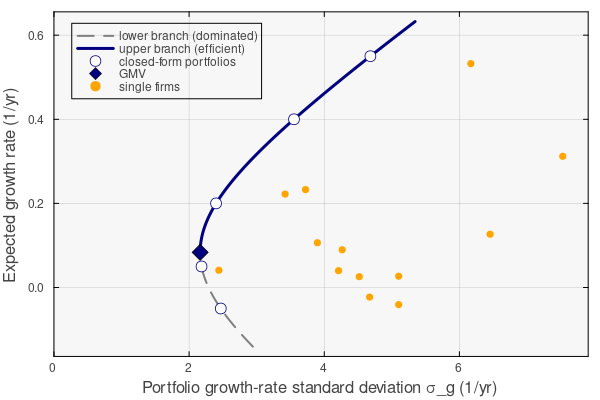

In [6]:
let
    g_range = range(minimum(ĝ) - 0.10, stop = maximum(ĝ) + 0.10, length = 301) |> collect;
    σ_range = sqrt.(frontier_variance.(g_range));
    upper = g_range .≥ b/a;
    plot(σ_range[.!upper], g_range[.!upper], c = :gray50, ls = :dash, label = "lower branch (dominated)")
    plot!(σ_range[upper], g_range[upper], c = :navy, lw = 3, label = "upper branch (efficient)")
    targets = [-0.05, 0.05, 0.20, 0.40, 0.55];
    scatter!([sqrt(frontier_variance(g)) for g ∈ targets], targets, ms = 6, c = :white, msc = :navy, label = "closed-form portfolios")
    scatter!([sqrt(1/a)], [b/a], ms = 8, c = :navy, marker = :diamond, label = "GMV")
    scatter!(sqrt.(diag(Σ̂_g)), ĝ, ms = 4, c = :orange, msc = :orange, label = "single firms")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", xlim = (0, 1.05*maximum(sqrt.(diag(Σ̂_g)))), legend = :topleft)
end

Every single firm lies on or to the right of the hyperbola, and the lower branch reaches negative growth rates: those are minimum-variance portfolios too, for targets nobody would choose.
___

## 2. The two-fund theorem
The closed form $\mathbf{w}(g_{\star})=\lambda(g_{\star})\mathbf{\Sigma}_{g}^{-1}\mathbf{1}+\gamma(g_{\star})\mathbf{\Sigma}_{g}^{-1}\bar{\mathbf{g}}$ is affine in $g_{\star}$, so the frontier is a straight line in weight space. Normalizing the two directions to portfolios, $\mathbf{w}_{\text{GMV}}=\mathbf{\Sigma}_{g}^{-1}\mathbf{1}/a$ and $\mathbf{w}_{D}=\mathbf{\Sigma}_{g}^{-1}\bar{\mathbf{g}}/b$ (which requires $b\neq0$), gives:
$$
\mathbf{w}(g_{\star}) = (1-\alpha)\,\mathbf{w}_{\text{GMV}} + \alpha\,\mathbf{w}_{D},\qquad \alpha = \gamma(g_{\star})\,b = \frac{b(a\,g_{\star}-b)}{d}
$$
because $\lambda a+\gamma b=(ac-b^{2})/d=1$. This is the __two-fund theorem__: every unconstrained frontier portfolio is a combination of two fixed frontier portfolios, with the mixing weight set by the target; the tangent portfolio of the lecture is one such combination. Let's verify the identity numerically at a few targets:

In [7]:
w_GMV = (Σ̂_g \ ones(M)) / a; # first fund
w_D = (Σ̂_g \ ĝ) / b; # second fund
@assert b != 0
let
    for g_target ∈ [-0.05, 0.10, 0.30, 0.55]
        α = b*(a*g_target - b)/d;
        w_mix = (1 - α)*w_GMV + α*w_D;
        @assert isapprox(w_mix, frontier_weights(g_target), atol = 1e-10)
        println("g⋆ = $(g_target): α = $(round(α, digits=3)); the two-fund mixture reproduces the frontier weights")
    end
end

g⋆ = -0.05: α = -0.189; the two-fund mixture reproduces the frontier weights
g⋆ = 0.1: α = 0.023; the two-fund mixture reproduces the frontier weights
g⋆ = 0.3: α = 0.306; the two-fund mixture reproduces the frontier weights
g⋆ = 0.55: α = 0.66; the two-fund mixture reproduces the frontier weights


Because any two distinct frontier portfolios span the same line, mixing __any__ two of them, in proportions that may be negative, traces the whole hyperbola. Let's mix the GMV portfolio and the second fund with $\alpha$ from $-1$ to $2.5$ and plot the resulting expected growth rates and standard deviations on top of the hyperbola:

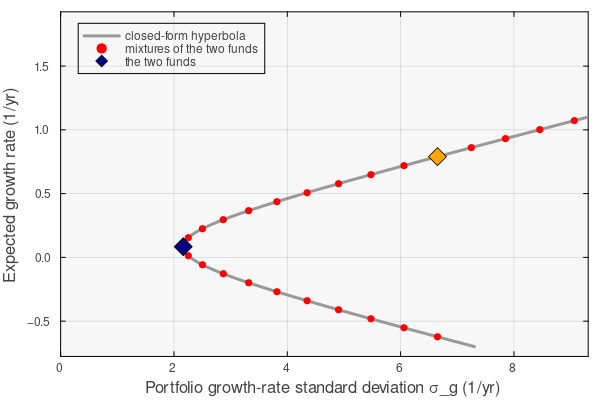

In [8]:
let
    g_range = range(-0.7, stop = 1.2, length = 301) |> collect;
    plot(sqrt.(frontier_variance.(g_range)), g_range, c = :gray60, lw = 3, label = "closed-form hyperbola")
    αs = range(-1.0, stop = 2.5, length = 36) |> collect;
    σ_mix = [sqrt(((1-α)*w_GMV + α*w_D)'*Σ̂_g*((1-α)*w_GMV + α*w_D)) for α ∈ αs];
    g_mix = [ĝ'*((1-α)*w_GMV + α*w_D) for α ∈ αs];
    scatter!(σ_mix, g_mix, ms = 4, c = :red, msc = :red, label = "mixtures of the two funds")
    scatter!([sqrt(w_GMV'*Σ̂_g*w_GMV), sqrt(w_D'*Σ̂_g*w_D)], [ĝ'*w_GMV, ĝ'*w_D], ms = 9, c = [:navy, :orange], marker = :diamond, label = "the two funds")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", xlim = (0, 1.4*sqrt(w_D'*Σ̂_g*w_D)), legend = :topleft)
end

Every mixture lands on the hyperbola. Negative $\alpha$ walks down the lower branch, $\alpha>1$ leverages the second fund up the upper branch. With a risk-free asset the same logic gives the lecture's separation result: the two funds become the risk-free asset and the tangent portfolio, and the frontier becomes the capital allocation line.
___

## 3. What constraints cost
The lecture's long-only frontier lies on or to the right of the unconstrained hyperbola. How far to the right, and how does an intermediate rule behave? We solve the equality-constrained problem with three feasible sets: unconstrained; short sales allowed but every position limited to $|w_{i}|\leq0.5$; and long-only, $0\leq w_{i}\leq1$. For each we sweep the target from the (feasible-set) GMV growth rate up to a common maximum and record the frontier standard deviation. We store the three frontiers in the `frontiers::Dict{String,DataFrame}` variable:

In [9]:
frontiers = let
    cases = [("unconstrained", -Inf, Inf), ("|w_i| ≤ 0.5", -0.5, 0.5), ("long only", 0.0, 1.0)];
    g_max = maximum(ĝ) - 1e-3; # the long-only set cannot exceed the best single firm
    out = Dict{String, DataFrame}();
    for (name, lo, hi) ∈ cases
        # the GMV growth rate of this feasible set: minimize variance with no target
        model = Model(() -> MadNLP.Optimizer(print_level = MadNLP.ERROR, max_iter = 500));
        @variable(model, lo ≤ w[i = 1:M] ≤ hi, start = 1/M);
        @objective(model, Min, w'*Σ̂_g*w); @constraint(model, sum(w) == 1.0); optimize!(model);
        g_min = ĝ'*value.(w);
        df = DataFrame(g = Float64[], σ = Float64[]);
        for g_target ∈ range(g_min, stop = g_max, length = 60)
            w_opt = solve_frontier_point(g_target; lower = lo, upper = hi);
            w_opt === nothing && continue
            push!(df, (g = g_target, σ = sqrt(w_opt'*Σ̂_g*w_opt)));
        end
        out[name] = df;
    end
    out; # return
end;
for name ∈ ["unconstrained", "|w_i| ≤ 0.5", "long only"]
    println(rpad(name, 14), ": $(nrow(frontiers[name])) frontier points, GMV growth = $(round(frontiers[name].g[1], digits=4)) 1/yr, GMV σ_g = $(round(frontiers[name].σ[1], digits=4)) 1/yr")
end

unconstrained : 60 frontier points, GMV growth = 0.0836 1/yr, GMV σ_g = 2.1635 1/yr
|w_i| ≤ 0.5   : 60 frontier points, GMV growth = 0.0919 1/yr, GMV σ_g = 2.1886 1/yr
long only     : 60 frontier points, GMV growth = 0.0818 1/yr, GMV σ_g = 2.1749 1/yr


Let's plot the three efficient branches, and tabulate the standard-deviation ratio relative to the unconstrained frontier at a few common targets (interpolating each frontier linearly in the target) [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/):

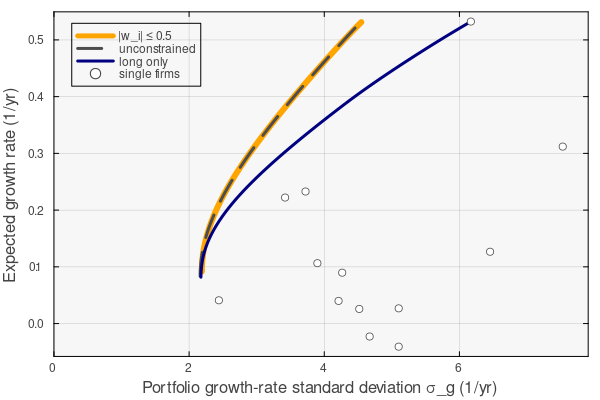

In [10]:
let
    plot()
    for (name, c, ls, lw) ∈ [("|w_i| ≤ 0.5", :orange, :solid, 6), ("unconstrained", :gray30, :dash, 3), ("long only", :navy, :solid, 3)]
        plot!(frontiers[name].σ, frontiers[name].g, c = c, ls = ls, lw = lw, label = name)
    end
    scatter!(sqrt.(diag(Σ̂_g)), ĝ, ms = 4, c = :white, msc = :gray30, label = "single firms")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)", xlim = (0, 1.05*maximum(sqrt.(diag(Σ̂_g)))), legend = :topleft)
end

In [11]:
let
    interp(df, g) = begin # linear interpolation of σ at target g (nothing if outside the range)
        (g < df.g[1] || g > df.g[end]) && return NaN
        k = searchsortedlast(df.g, g); k == nrow(df) && return df.σ[end]
        df.σ[k] + (df.σ[k+1] - df.σ[k])*(g - df.g[k])/(df.g[k+1] - df.g[k])
    end
    targets = [0.10, 0.20, 0.30, 0.40, 0.50];
    df = DataFrame(g_target = targets,
        σ_unconstrained = [round(interp(frontiers["unconstrained"], g), digits=3) for g ∈ targets],
        ratio_box = [round(interp(frontiers["|w_i| ≤ 0.5"], g)/interp(frontiers["unconstrained"], g), digits=3) for g ∈ targets],
        ratio_long_only = [round(interp(frontiers["long only"], g)/interp(frontiers["unconstrained"], g), digits=3) for g ∈ targets]);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ---------- ----------------- ----------- -----------------
  g_target   σ_unconstrained   ratio_box   ratio_long_only 
   Float64           Float64     Float64           Float64 
 ---------- ----------------- ----------- -----------------
       0.1             2.169        1.01             1.007
       0.2             2.399       1.001             1.067
       0.3             2.897         1.0             1.171
       0.4             3.552         1.0             1.253
       0.5             4.293         1.0             1.331
 ---------- ----------------- ----------- -----------------


The position limit binds only where the unconstrained solution wants more than half the budget in one name. Here that happens near the minimum-variance end, where the unconstrained solution puts more than 60% in the health-care firm, so the box costs about a percent of standard deviation there and nothing at higher targets, where the unconstrained weights stay inside $\pm0.5$ (the box frontier sits on top of the unconstrained one and hides it in the plot). The long-only constraint costs more the higher the target, because the unconstrained solution finances the high-growth names with short positions the long-only rule forbids, and it cannot reach targets above the best single firm at all. Whether the extra variance is worth paying is a question about estimation error, not geometry: the estimation-risk notebook shows the constrained solutions are far more stable.
___

## Summary

This notebook made the lecture's frontier geometry explicit for our own data: the equality-constrained problem has a closed-form solution that is affine in the target, the frontier is a hyperbola generated by two fixed portfolios, and constraints shrink the feasible set only where the unconstrained solution would have violated them.

> __Key Takeaways:__
>
> - **The frontier is a line in weight space and a hyperbola in the risk-growth plane:** Two Lagrange multipliers give closed-form weights for every target, the minimum variance is quadratic in the target, and a numerical solver reproduces both to tolerance.
> - **Two funds are enough:** Every unconstrained frontier portfolio is an affine combination of the global minimum-variance portfolio and one other frontier portfolio, and mixing any two frontier portfolios, with negative or leveraged proportions, traces the entire hyperbola.
> - **Constraints cost variance only where they bind:** A position limit moves the frontier only where the unconstrained solution concentrates in one name (here near the minimum-variance end), while the long-only frontier lies on or to the right of the hyperbola at every target, increasingly far as the target rises, and stops at the best single firm.

The geometry says what the optimizer can reach; the estimation-risk notebook says how much of that reach is real.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___